# Filtro de Particulas INDEPENDIENTE -- sin warm-start del Kalman Filter

**Proyecto KJM -- ?Cuanto del buen desempeno del PF era prestado?**

---

## La pregunta que motiva este notebook

En el notebook anterior (`DNS_DNSS_FiltroParticulas`), el Particle Filter superaba
consistentemente al Kalman Filter en RMSE y en recuperacion de tau_t. Pero hay una
razon estructural para sospechar de esa comparacion: **el PF no estimaba sus propios
parametros** -- los heredaba directamente del MLE del Kalman Filter.

Mira la tabla de donde viene cada parametro en `fit_pf_model()`:

| Parametro del PF | De donde viene | Optimizado para... |
|---|---|---|
| `mu_beta`, `F_beta_diag`, `Q_beta_diag` | `res_kf['mu']`, `np.diag(res_kf['F'])`, `np.diag(res_kf['Q'])` | minimizar la verosimilitud negativa del KF, **condicional en tau fijo** (grid search) |
| `R_diag` | `res_kf['R_diag']` | idem -- el mismo MLE del KF |
| `mu_ltau`, `phi_ltau`, `q_ltau` | OLS sobre la serie `tau1_t` del propio KF | calibracion nueva, pero basada en una serie ya filtrada por el KF |

El problema: el MLE del KF ya **optimizo R y Q para minimizar el error residual** de
un modelo con tau fijo. Cuando el PF hereda ese R y Q, y **ademas** le da libertad
extra a tau_t para moverse en el tiempo, el resultado *mecanicamente* va a ajustar
mejor -- no porque el proceso generador real tenga tau dinamico, sino porque el PF
recibe un punto de partida ya optimizado MAS una dimension de libertad adicional.
Es comparar un modelo con 3+3+3+6=15 parametros ya afinados, mas 3 nuevos, contra un
modelo de 15 parametros sin los 3 nuevos -- la comparacion esta inclinada desde el
diseno, independientemente de si tau_t dinamico es realmente la explicacion correcta.

## Que vamos a hacer en este notebook

Reconstruir el PF desde cero, sin que ningun parametro pase por el Kalman Filter:

1. **Ajuste OLS transversal periodo-por-periodo** (sin filtro, sin suavizado --
   pura regresion de minimos cuadrados en cada fecha) para obtener una serie cruda
   de beta_t y tau_t
2. **AR(1) por factor via OLS cerrado** sobre esa serie cruda -- sin MLE, sin
   Kalman, solo formulas cerradas de regresion lineal
3. **Diagnostico honesto de los sesgos** que esto introduce (sesgo de atenuacion
   en la persistencia F, inflacion de Q, deflacion de R) -- vamos a mostrar
   exactamente por que el OLS "ingenuo" tambien tiene sus propios problemas, no
   es magicamente mejor, solo es *independiente*
4. **Auto-calibracion**: ajustar un par de escalas globales (sobre Q y R) maximizando
   la propia verosimilitud del PF -- sin tocar el KF en ningun momento
5. **Comparacion final de tres vias**: KF | PF "heredado" (notebook anterior) | PF
   independiente (este notebook)

El **motor matematico del PF en si (la seccion de mas abajo) es exactamente el mismo**
que en el notebook anterior -- no cambia nada del algoritmo SIR. Lo unico que cambia
es **de donde vienen los numeros que se le dan de comer**.

## 1. Imports y configuracion global

In [1]:
import numpy as np
import pandas as pd
import os, sys, time, warnings
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

warnings.filterwarnings('ignore')
np.random.seed(42)

try:
    from numba import njit as _njit
    _NUMBA = True
except ImportError:
    _NUMBA = False
    def _njit(**kw):
        return lambda f: f

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.22, 'font.size': 10,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.framealpha': 0.85, 'legend.fontsize': 9,
})
COLORES_FACTOR = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
COLOR_PF_HER   = '#7f7f7f'   # PF "heredado" (notebook anterior) -- gris, referencia
COLOR_PF_IND   = '#d62728'   # PF independiente (este notebook) -- rojo, protagonista
COLOR_KF       = '#1f77b4'   # KF -- azul

print("Numba disponible:", _NUMBA)

Numba disponible: True


## 2. Carga de datos

Mismo generador sintetico validado en el notebook anterior: beta_t sigue un AR(1)
diagonal, log(tau_t) sigue un AR(1) independiente -- esto nos permite, igual que
antes, comparar contra la **verdad conocida** del proceso generador, algo que con
datos reales de TES nunca podriamos hacer directamente.

In [2]:

RUTA_DATOS = r"C:\\Users\\ADMON\\Documents\\Universidad\\Proyecto KMJ\\codigo\\TES_colombia\\curvas_panel_historico_limpio.csv"

if os.path.exists(RUTA_DATOS):
    raw = pd.read_csv(RUTA_DATOS)
    yield_cols = ["r_2yr","r_3yr","r_5yr","r_7yr","r_10yr","r_15yr"]
    maturities = np.array([2,3,5,7,10,15], dtype=float)
    df = raw[["fecha"]+yield_cols].copy()
    df["fecha"] = pd.to_datetime(df["fecha"])
    df = df.dropna(subset=yield_cols).sort_values("fecha").reset_index(drop=True)
    yields_data = df[yield_cols].values
    dates_dt = pd.DatetimeIndex(df["fecha"].values)
    fuente = "TES Colombia"
    _SINTETICO_TRUE = None
else:
    rng0 = np.random.default_rng(7)
    T_sim = 1200
    maturities = np.array([2.,3.,5.,7.,10.,15.])
    Nm = len(maturities)

    mu_beta_true  = np.array([7.0, -2.5, 2.0])
    F_beta_true   = np.array([0.997, 0.985, 0.97])
    sig_eta_true  = np.array([0.012, 0.020, 0.028])
    mu_ltau_true  = np.log(1.8)
    phi_ltau_true = 0.995
    sig_ltau_true = 0.02
    R_true        = np.full(Nm, 0.015**2)

    beta_true = np.zeros((T_sim,3)); ltau_true = np.zeros(T_sim)
    beta_true[0] = mu_beta_true; ltau_true[0] = mu_ltau_true
    for t in range(1, T_sim):
        beta_true[t]  = mu_beta_true + F_beta_true*(beta_true[t-1]-mu_beta_true) + rng0.standard_normal(3)*sig_eta_true
        ltau_true[t]  = mu_ltau_true + phi_ltau_true*(ltau_true[t-1]-mu_ltau_true) + rng0.standard_normal()*sig_ltau_true

    def _ns_H_simple(m, tau):
        mt = m/tau; e = np.exp(-mt); c = (1-e)/mt
        return np.column_stack([np.ones_like(m), c, c-e])

    yields_data = np.zeros((T_sim, Nm))
    for t in range(T_sim):
        Ht = _ns_H_simple(maturities, np.exp(ltau_true[t]))
        yields_data[t] = Ht @ beta_true[t] + rng0.standard_normal(Nm)*np.sqrt(R_true)

    dates_dt   = pd.bdate_range("2015-01-02", periods=T_sim)
    yield_cols = [f"Y{int(m)}Y" for m in maturities]
    df         = pd.DataFrame(yields_data, index=dates_dt, columns=yield_cols)
    fuente     = "Sintetico: proceso generador log-AR(1) en tau1 + AR(1) en beta"
    _SINTETICO_TRUE = dict(beta_true=beta_true, tau1_true=np.exp(ltau_true), R_true=R_true,
                            mu_beta=mu_beta_true, F_beta=F_beta_true, sig_eta=sig_eta_true,
                            mu_ltau=mu_ltau_true, phi_ltau=phi_ltau_true, sig_ltau=sig_ltau_true)

T, N = yields_data.shape
print(f"Fuente : {fuente}")
print(f"T={T}  N={N}  plazos={maturities}")
print(f"Rango  : {dates_dt[0].date()} -> {dates_dt[-1].date()}")


Fuente : Sintetico: proceso generador log-AR(1) en tau1 + AR(1) en beta
T=1200  N=6  plazos=[ 2.  3.  5.  7. 10. 15.]
Rango  : 2015-01-02 -> 2019-08-08


## 3. Cargas Nelson-Siegel (DNS)

Identicas a las de siempre. Este notebook se enfoca en DNS para aislar el punto
metodologico con la maxima claridad posible (DNSS agrega una dimension mas de
complejidad -- el label-switching -- que no es el foco aqui).

In [3]:
def ns_loadings(maturities, tau1):
    m = np.asarray(maturities, dtype=float)
    mt = m/tau1; e = np.exp(-mt); c = (1.0-e)/mt
    return np.column_stack([np.ones_like(m), c, c-e])

def nss_loadings(maturities, tau1, tau2):
    m = np.asarray(maturities, dtype=float)
    mt1=m/tau1; mt2=m/tau2; e1=np.exp(-mt1); e2=np.exp(-mt2)
    c1=(1.0-e1)/mt1
    return np.column_stack([np.ones_like(m), c1, c1-e1, (1.0-e2)/mt2-e2])

def build_H_array(maturities, tau1_t, tau2_t=None, model='DNS'):
    T_obs = len(tau1_t)
    if model == 'DNS':
        return np.array([ns_loadings(maturities, tau1_t[t]) for t in range(T_obs)])
    return np.array([nss_loadings(maturities, tau1_t[t], tau2_t[t]) for t in range(T_obs)])

def aic_bic(loglik, k, T):
    aic = 2*k - 2*loglik
    bic = k*np.log(T) - 2*loglik
    return float(aic), float(bic)

## 4. Nucleo del Particle Filter -- sin cambios respecto al notebook anterior

Esta celda es **exactamente** el mismo codigo de `DNS_DNSS_FiltroParticulas`:
calibracion AR(1) de tau, la matematica vectorizada del Bootstrap PF (prediccion,
pesos, ESS, remuestreo sistematico), la barra de progreso, y el loop principal
`run_particle_filter()`. Esto es deliberado -- el punto de este notebook NO es
cambiar el algoritmo del filtro, sino cambiar **de donde vienen sus parametros**.
Si el algoritmo fuera distinto, no podriamos atribuir limpiamente cualquier
diferencia de resultados a la fuente de los parametros.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CALIBRACIÓN DE LA DINÁMICA AR(1) DE τ
# ═══════════════════════════════════════════════════════════════════════════════

def calibrate_tau_ar1(tau_t: np.ndarray,
                      floor_phi: float = 0.80,
                      cap_phi: float = 0.999) -> tuple:
    """
    Calibra (mu_ltau, phi_ltau, q_ltau) vía OLS sobre log(tau_t), usando la
    serie ya producida por rolling_tau_dns/rolling_tau_dnss (grid_search.py)
    como si fuera "data observada" de τ.

    Advertencia metodológica: tau_t del grid search es ya una versión
    filtrada/discretizada (ventana móvil + grid discreto) del proceso
    continuo subyacente. Su varianza empírica de innovaciones SUBESTIMA
    la verdadera varianza de innovación de τ — es un límite inferior, no
    un valor exacto. Por eso fit_pf_model() expone `q_ltau_scale` para
    poder inflarla.

    Retorna
    -------
    (mu_ltau, phi_ltau, q_ltau) : float, float, float
    """
    ltau = np.log(np.asarray(tau_t, dtype=float))
    y, x = ltau[1:], ltau[:-1]
    xm, ym = x.mean(), y.mean()
    phi = np.sum((x - xm) * (y - ym)) / np.sum((x - xm) ** 2)
    phi = float(np.clip(phi, floor_phi, cap_phi))
    intercept = ym - phi * xm
    mu_ltau = intercept / (1 - phi)
    resid = y - (intercept + phi * x)
    q_ltau = float(resid.var(ddof=1))
    return mu_ltau, phi, q_ltau


# ═══════════════════════════════════════════════════════════════════════════════
# NÚCLEO MATEMÁTICO DEL PF (vectorizado sobre el eje de partículas)
# ═══════════════════════════════════════════════════════════════════════════════

def predicted_yields(maturities: np.ndarray, beta: np.ndarray,
                     ltau: np.ndarray, model: str) -> np.ndarray:
    """y_hat (N_particulas, N_madurez) para un lote completo de partículas."""
    tau1 = np.exp(ltau[:, 0])
    m = maturities[None, :]
    mt1 = m / tau1[:, None]
    e1 = np.exp(-mt1)
    c1 = (1.0 - e1) / mt1
    y_hat = beta[:, 0:1] * 1.0 + beta[:, 1:2] * c1 + beta[:, 2:3] * (c1 - e1)
    if model == 'DNSS':
        tau2 = np.exp(ltau[:, 1])
        mt2 = m / tau2[:, None]
        e2 = np.exp(-mt2)
        c2 = (1.0 - e2) / mt2
        y_hat = y_hat + beta[:, 3:4] * (c2 - e2)
    return y_hat


def propagate_beta(beta_prev, mu_beta, F_diag, sqrtQ_diag, rng):
    """Un paso del AR(1) diagonal de los factores beta."""
    noise = rng.standard_normal(beta_prev.shape) * sqrtQ_diag[None, :]
    return mu_beta[None, :] + (beta_prev - mu_beta[None, :]) * F_diag[None, :] + noise


def propagate_tau(ltau_prev, mu_ltau, phi_ltau, sqrtq_ltau, rng):
    """Un paso del AR(1) de log-tau (independiente por cada tau)."""
    noise = rng.standard_normal(ltau_prev.shape) * sqrtq_ltau[None, :]
    return mu_ltau[None, :] + (ltau_prev - mu_ltau[None, :]) * phi_ltau[None, :] + noise


def enforce_tau_order(ltau, sep_min, tau_floor=0.05):
    """
    Restricción direccional para DNSS: tau1 (hump largo) > tau2 (hump corto)
    + sep_min — la misma restricción de identificación de
    grid_search.rolling_tau_dnss, pero aplicada PARTÍCULA POR PARTÍCULA en
    cada periodo (no solo descartando pares inválidos de un grid estático).
    Se ordena por magnitud (resuelve el label-switching por construcción) y
    se empuja hacia abajo el menor si la separación no se cumple.
    """
    tau = np.exp(ltau)
    tau_hi = np.maximum(tau[:, 0], tau[:, 1])
    tau_lo = np.minimum(tau[:, 0], tau[:, 1])
    deficit = np.maximum(sep_min - (tau_hi - tau_lo), 0.0)
    tau_lo_new = np.maximum(tau_lo - deficit, tau_floor)
    return np.log(np.column_stack([tau_hi, tau_lo_new]))


def gaussian_loglik(y_t, y_hat, R_diag):
    """log p(y_t | particula) bajo innovaciones Gaussianas independientes."""
    resid = y_t[None, :] - y_hat
    return -0.5 * np.sum(resid ** 2 / R_diag[None, :] + np.log(2 * np.pi * R_diag[None, :]), axis=1)


def student_t_loglik(y_t, y_hat, R_diag, nu):
    """
    log p(y_t | particula) bajo innovaciones Student-t independientes
    (colas pesadas). La escala se calibra para que Var coincida con R_diag
    cuando nu > 2. Relevante directamente para el hallazgo de colas pesadas
    en los QQ-plots de diagnostics.residual_stats.
    """
    resid = y_t[None, :] - y_hat
    scale2 = R_diag * (nu - 2.0) / nu
    z2 = resid ** 2 / scale2[None, :]
    c = gammaln((nu + 1) / 2) - gammaln(nu / 2) - 0.5 * np.log(nu * np.pi * scale2)
    return np.sum(c[None, :] - ((nu + 1) / 2) * np.log(1 + z2 / nu), axis=1)


def _normalize_log_weights(logw):
    mx = np.max(logw)
    w = np.exp(logw - mx)
    s = w.sum()
    return w / s, mx + np.log(s)


def _ess(w):
    """Effective Sample Size = 1 / sum(w_i^2), con w normalizado."""
    return 1.0 / np.sum(w ** 2)


def systematic_resample(w, rng):
    """Remuestreo sistemático — menor varianza que el multinomial puro para el mismo N."""
    Np = len(w)
    positions = (rng.random() + np.arange(Np)) / Np
    cumsum = np.cumsum(w)
    cumsum[-1] = 1.0
    return np.searchsorted(cumsum, positions)


# ═══════════════════════════════════════════════════════════════════════════════
# BARRA DE PROGRESO (sin dependencias externas)
# ═══════════════════════════════════════════════════════════════════════════════

def _format_eta(seconds):
    seconds = max(0, seconds)
    if seconds >= 60:
        return f"{int(seconds // 60)}m{int(seconds % 60):02d}s"
    return f"{seconds:.1f}s"


def _pf_progress_bar(t, T, t0_wall, ess_ratio, n_resampled, bar_width=28):
    """
    Barra de una sola línea (se sobreescribe con \\r). El KF es cerrado y
    rapidísimo; el PF escala con N_particulas y puede tardar de segundos a
    minutos — de ahí que convenga monitorear progreso, ESS y ETA en vivo.
    """
    frac = (t + 1) / T
    elapsed = time.time() - t0_wall
    rate = (t + 1) / elapsed if elapsed > 0 else 0.0
    eta = (T - (t + 1)) / rate if rate > 0 else float('nan')
    filled = int(bar_width * frac)
    bar = '#' * filled + '-' * (bar_width - filled)
    msg = (f"\r  [{bar}] {frac*100:5.1f}%  t={t+1}/{T}  "
           f"ESS/N={ess_ratio:4.2f}  remuestreos={n_resampled}  "
           f"{rate:,.0f} it/s  transcurrido={_format_eta(elapsed)}  ETA={_format_eta(eta)}   ")
    sys.stdout.write(msg)
    sys.stdout.flush()


# ═══════════════════════════════════════════════════════════════════════════════
# LOOP PRINCIPAL — SEQUENTIAL IMPORTANCE RESAMPLING (SIR)
# ═══════════════════════════════════════════════════════════════════════════════

def run_particle_filter(yields, maturities, model, n_particles, params, config,
                        show_progress=True, progress_every=None):
    """
    Bootstrap Particle Filter (SIR con remuestreo adaptativo por ESS) sobre
    el estado aumentado x_t = (beta_t, log-tau_t).

    Para cada periodo t: (1) predicción — propagar cada partícula con la
    transición AR(1); (2) verosimilitud incremental p(y_t|x_t^(i));
    (3) actualización de pesos w_t ∝ w_{t-1}·p(y_t|x_t); (4) log-verosimilitud
    marginal acumulada (estimación SMC); (5) remuestreo condicional por ESS.

    Disciplina OOS: se guardan por separado x_pred_mean (β̂_{t|t-1}, ANTES
    de ver y_t) y x_filt_mean (β̂_{t|t}, DESPUÉS) — la misma distinción que
    forecasting.py aplica para el KF y el Gibbs (β predichos, no suavizados,
    para evaluación fuera de muestra).

    Parámetros
    ----------
    yields, maturities, model : igual convención que el resto del paquete
    n_particles : int
        Número de partículas N. Determina la varianza de Monte Carlo del
        log-lik y de los estados estimados. Punto de partida razonable:
        1000-5000; validar con un análisis de sensibilidad.
    params : dict
        mu_beta, F_beta_diag, Q_beta_diag : dinámica de beta (warm-start del KF)
        mu_ltau, phi_ltau, q_ltau         : dinámica AR(1) de log(tau) —
                                            arrays shape (1,) en DNS, (2,) en DNSS
        R_diag                             : varianza de medición por plazo
    config : dict
        seed             : semilla (CRÍTICO — el PF tiene varianza de Monte
                           Carlo finita en N, a diferencia del KF)
        ess_threshold    : fracción de N bajo la cual se dispara el remuestreo
        sep_min          : separación mínima tau1 > tau2 + sep_min (solo DNSS)
        innovation_dist  : 'gaussian' | 'student_t'
        student_t_df     : grados de libertad si innovation_dist=='student_t'
    show_progress : bool
        Barra de progreso de una sola línea con ETA y velocidad (it/s).
    progress_every : int | None
        Cada cuántos periodos actualizar la barra (None → automático, ~200
        actualizaciones en total).

    Retorna
    -------
    dict con un esquema de claves compatible con el resultado del KF
    (beta_filtered, tau1_t, tau2_t, residuals, fitted, rmse_total, ...) más
    diagnósticos propios del PF: ess_t, resampled_t, x_filt_mean, x_filt_std,
    loglik, aic, bic.
    """
    T, Nm = yields.shape
    n_beta = 3 if model == 'DNS' else 4
    n_tau = 1 if model == 'DNS' else 2
    rng = np.random.default_rng(config.get('seed', 0))

    mu_beta = params['mu_beta']; F_diag = params['F_beta_diag']
    sqrtQ = np.sqrt(params['Q_beta_diag'])
    mu_ltau = np.atleast_1d(params['mu_ltau']); phi_ltau = np.atleast_1d(params['phi_ltau'])
    sqrtq_ltau = np.sqrt(np.atleast_1d(params['q_ltau']))
    R_diag = params['R_diag']
    sep_min = config.get('sep_min', 0.30)
    ess_thr = config.get('ess_threshold', 0.5) * n_particles
    dist = config.get('innovation_dist', 'gaussian')
    nu = config.get('student_t_df', 5.0)

    P0_beta = params['Q_beta_diag'] / np.maximum(1 - F_diag ** 2, 1e-6)
    beta = mu_beta[None, :] + rng.standard_normal((n_particles, n_beta)) * np.sqrt(P0_beta)[None, :]
    var0_ltau = np.atleast_1d(params['q_ltau']) / np.maximum(1 - phi_ltau ** 2, 1e-6)
    ltau = mu_ltau[None, :] + rng.standard_normal((n_particles, n_tau)) * np.sqrt(var0_ltau)[None, :]
    if model == 'DNSS':
        ltau = enforce_tau_order(ltau, sep_min)
    w = np.full(n_particles, 1.0 / n_particles)

    kdim = n_beta + n_tau
    x_filt_mean = np.zeros((T, kdim)); x_filt_std = np.zeros((T, kdim))
    x_pred_mean = np.zeros((T, kdim))
    fitted_pred = np.zeros((T, Nm)); fitted_filt = np.zeros((T, Nm))
    ess_t = np.zeros(T); resampled_t = np.zeros(T, dtype=bool)
    loglik = 0.0

    if progress_every is None:
        progress_every = max(1, T // 200)
    t0_wall = time.time()
    n_resampled_so_far = 0

    for t in range(T):
        beta_pred = propagate_beta(beta, mu_beta, F_diag, sqrtQ, rng)
        ltau_pred = propagate_tau(ltau, mu_ltau, phi_ltau, sqrtq_ltau, rng)
        if model == 'DNSS':
            ltau_pred = enforce_tau_order(ltau_pred, sep_min)

        y_hat_pred = predicted_yields(maturities, beta_pred, ltau_pred, model)
        x_t = np.hstack([beta_pred, ltau_pred])
        fitted_pred[t] = w @ y_hat_pred
        x_pred_mean[t] = w @ x_t

        ll_i = (gaussian_loglik(yields[t], y_hat_pred, R_diag) if dist == 'gaussian'
                else student_t_loglik(yields[t], y_hat_pred, R_diag, nu))
        logw_unnorm = np.log(w + 1e-300) + ll_i
        w_new, log_sum = _normalize_log_weights(logw_unnorm)
        loglik += log_sum

        fitted_filt[t] = w_new @ y_hat_pred
        x_filt_mean[t] = w_new @ x_t
        var_filt = w_new @ (x_t ** 2) - x_filt_mean[t] ** 2
        x_filt_std[t] = np.sqrt(np.maximum(var_filt, 0))

        ess_val = _ess(w_new); ess_t[t] = ess_val
        if ess_val < ess_thr:
            idx = systematic_resample(w_new, rng)
            beta, ltau = beta_pred[idx], ltau_pred[idx]
            w = np.full(n_particles, 1.0 / n_particles)
            resampled_t[t] = True
            n_resampled_so_far += 1
        else:
            beta, ltau = beta_pred, ltau_pred
            w = w_new
            resampled_t[t] = False

        if show_progress and ((t + 1) % progress_every == 0 or t == T - 1):
            _pf_progress_bar(t, T, t0_wall, ess_val / n_particles, n_resampled_so_far)

    if show_progress:
        sys.stdout.write('\n'); sys.stdout.flush()

    # ── Empaquetado en esquema compatible con kalman_filter / generate_full_report ──
    tau1_t = np.exp(x_filt_mean[:, n_beta])
    tau2_t = np.exp(x_filt_mean[:, n_beta + 1]) if model == 'DNSS' else None
    beta_filtered = x_filt_mean[:, :n_beta]

    H_arr_pf = build_H_array(maturities, tau1_t, tau2_t, model)
    resid = yields - fitted_filt
    rmse_total = np.sqrt(np.mean(resid ** 2)); mae_total = np.mean(np.abs(resid))
    rmse_mat = np.sqrt(np.mean(resid ** 2, axis=0)); mae_mat = np.mean(np.abs(resid), axis=0)

    k_nuevo_tau = 3 * n_tau   # mu_ltau, phi_ltau, q_ltau por cada tau (lo que el PF agrega)
    aic_pf, bic_pf = aic_bic(loglik, k_nuevo_tau, T)

    return dict(
        model=model, n_particles=n_particles, tau1_t=tau1_t, tau2_t=tau2_t,
        H_arr=H_arr_pf, R_diag=R_diag,
        beta_filtered=beta_filtered, beta_smoothed=beta_filtered,   # no hay smoother — ver docstring
        x_filt_mean=x_filt_mean, x_filt_std=x_filt_std, x_pred_mean=x_pred_mean,
        fitted=fitted_filt, fitted_pred=fitted_pred, residuals=resid,
        loglik=loglik, aic=aic_pf, bic=bic_pf, k_nuevo=k_nuevo_tau,
        rmse_total=rmse_total, mae_total=mae_total,
        rmse_mat=rmse_mat, mae_mat=mae_mat,
        ess_t=ess_t, resampled_t=resampled_t,
        maturities=maturities, dates=None, yields=yields,
        innovation_dist=dist, student_t_df=nu, sep_min=sep_min,
    )




## 5. Kalman Filter compacto -- solo para reconstruir el punto de comparacion

Esta seccion reconstruye el KF y el "PF heredado" (con warm-start del KF, igual
que en el notebook anterior) **unicamente como punto de referencia** -- para poder
comparar de forma directa, en el mismo notebook, los tres resultados: KF, PF
heredado, PF independiente. No es el foco de este notebook; si ya tienes el
resultado guardado del notebook anterior, podrias cargarlo en vez de recalcularlo.

In [5]:
@_njit(cache=True)
def _kf_core(yields, H_arr, F, Q, R_diag, mu, beta0, P0):
    T_obs, N_obs = yields.shape
    k_dim = F.shape[0]; Ik = np.eye(k_dim); LOG2PI = np.log(2.0*np.pi)
    beta_pred_all=np.zeros((T_obs,k_dim)); beta_filt_all=np.zeros((T_obs,k_dim))
    P_pred_all=np.zeros((T_obs,k_dim,k_dim)); P_filt_all=np.zeros((T_obs,k_dim,k_dim))
    innov_all=np.zeros((T_obs,N_obs)); loglik=0.0
    beta=beta0.copy(); P=P0.copy()
    for t in range(T_obs):
        beta_p = mu + F@(beta-mu); P_p = F@P@F.T+Q; P_p=0.5*(P_p+P_p.T)
        beta_pred_all[t]=beta_p; P_pred_all[t]=P_p
        Ht = H_arr[t]; v = yields[t]-Ht@beta_p; HP = Ht@P_p; S = HP@Ht.T
        for n in range(N_obs): S[n,n]+=R_diag[n]
        S=0.5*(S+S.T)
        L_chol=np.linalg.cholesky(S+1e-10*np.eye(N_obs))
        log_det=0.0
        for n in range(N_obs): log_det+=np.log(L_chol[n,n])
        log_det*=2.0
        z=np.linalg.solve(L_chol,v); quad=np.dot(z,z)
        loglik += -0.5*(N_obs*LOG2PI+log_det+quad); innov_all[t]=v
        Z=np.linalg.solve(L_chol,HP); Kt=np.linalg.solve(L_chol.T,Z); K=Kt.T
        beta=beta_p+K@v
        Rmat=np.zeros((N_obs,N_obs))
        for n in range(N_obs): Rmat[n,n]=R_diag[n]
        IKH=Ik-K@Ht; P=IKH@P_p@IKH.T+K@Rmat@K.T; P=0.5*(P+P.T)
        beta_filt_all[t]=beta; P_filt_all[t]=P
    return beta_pred_all,beta_filt_all,P_pred_all,P_filt_all,innov_all,loglik


def build_H_array(maturities, tau1_t, tau2_t, model):
    T_obs=len(tau1_t); k=3 if model=='DNS' else 4; N=len(maturities)
    H_arr=np.zeros((T_obs,N,k))
    for t in range(T_obs):
        H_arr[t]= ns_loadings(maturities, tau1_t[t]) if model=='DNS' else nss_loadings(maturities, tau1_t[t], tau2_t[t])
    return H_arr

def compute_P0_stationary(F, Q):
    f_vec=np.diag(F); q_vec=np.diag(Q)
    return np.diag(q_vec/np.maximum(1-f_vec**2,1e-6))# ── CELDA 4: Rolling Grid Search de tau_t (reutilizado) ─────────────────────
def _residual_maker(H):
    N,k = H.shape; HtH=H.T@H
    if np.linalg.cond(HtH) > 1e12: return None
    try: return np.eye(N) - H@np.linalg.solve(HtH, H.T)
    except np.linalg.LinAlgError: return None

def _build_YYt_cumsum(yields):
    T,N = yields.shape; YYt=np.zeros((T+1,N,N))
    for t in range(T):
        yt=yields[t]; YYt[t+1]=YYt[t]+np.outer(yt,yt)
    return YYt

def rolling_tau_dns(yields, maturities, tau1_grid, window_size=None):
    T,N=yields.shape; G1=len(tau1_grid); k=3
    M_list=[]
    for tau1 in tau1_grid:
        H=ns_loadings(maturities,tau1); Mv=_residual_maker(H)
        M_list.append(Mv if Mv is not None else np.eye(N))
    M_arr=np.stack(M_list,axis=0); YYt_cum=_build_YYt_cumsum(yields); default=G1//2
    tau1_t=np.zeros(T); sse_t=np.zeros(T)
    for t in range(T):
        if window_size is None: Sigma=YYt_cum[t+1]; n_win=t+1
        else:
            t0=max(0,t-window_size+1); Sigma=YYt_cum[t+1]-YYt_cum[t0]; n_win=t-t0+1
        if n_win < k+2: tau1_t[t]=tau1_grid[default]; continue
        sse_vec=np.einsum('gij,ji->g', M_arr, Sigma)
        best_g=np.argmin(sse_vec); tau1_t[t]=tau1_grid[best_g]; sse_t[t]=sse_vec[best_g]
    return tau1_t, sse_t

def rolling_tau_dnss(yields, maturities, tau1_grid, tau2_grid, window_size=None, sep_min=0.30):
    T,N=yields.shape; G1,G2=len(tau1_grid),len(tau2_grid); k=4
    M_arr=np.zeros((G1,G2,N,N)); valid=np.zeros((G1,G2),dtype=bool)
    for i,tau1 in enumerate(tau1_grid):
        for j,tau2 in enumerate(tau2_grid):
            if tau1 <= tau2+sep_min: continue
            H=nss_loadings(maturities,tau1,tau2); Mv=_residual_maker(H)
            if Mv is not None: M_arr[i,j]=Mv; valid[i,j]=True
    YYt_cum=_build_YYt_cumsum(yields)
    valid_pairs=np.argwhere(valid)
    if len(valid_pairs)==0: raise ValueError("No hay pares validos")
    mid=len(valid_pairs)//2; di,dj=valid_pairs[mid]
    tau1_t=np.zeros(T); tau2_t=np.zeros(T); sse_t=np.zeros(T)
    for t in range(T):
        if window_size is None: Sigma=YYt_cum[t+1]; n_win=t+1
        else:
            t0=max(0,t-window_size+1); Sigma=YYt_cum[t+1]-YYt_cum[t0]; n_win=t-t0+1
        if n_win < k+2: tau1_t[t]=tau1_grid[di]; tau2_t[t]=tau2_grid[dj]; continue
        sse_grid=np.einsum('ghjk,kj->gh', M_arr, Sigma); sse_grid[~valid]=np.inf
        flat=np.argmin(sse_grid.ravel()); bi,bj=np.unravel_index(flat,(G1,G2))
        tau1_t[t]=tau1_grid[bi]; tau2_t[t]=tau2_grid[bj]; sse_t[t]=sse_grid[bi,bj]
    return tau1_t, tau2_t, sse_t# ── CELDA 5: MLE (mu,F,Q,R) dado H_t — version compacta F diagonal, R libre ──
def pack_params(mu,F,Q_diag,R_diag,k):
    p=list(mu); f_vec=np.clip(np.diag(F),-0.994,0.994); p+=list(np.arctanh(f_vec/0.995))
    p+=list(np.log(np.maximum(Q_diag,1e-10))); p+=list(np.log(np.maximum(R_diag,1e-10)))
    return np.array(p)

def unpack_params(params,k,N):
    idx=0; mu=params[idx:idx+k]; idx+=k
    x=params[idx:idx+k]; idx+=k; F=np.diag(0.995*np.tanh(x))
    Q_diag=np.exp(params[idx:idx+k]); idx+=k
    R_diag=np.exp(params[idx:idx+N])
    return mu,F,np.diag(Q_diag),Q_diag,R_diag

def neg_loglik(params,yields,H_arr,k,N):
    mu,F,Q,Q_diag,R_diag = unpack_params(params,k,N)
    P0=compute_P0_stationary(F,Q); beta0=mu.copy()
    try:
        _,_,_,_,_,loglik=_kf_core(yields,H_arr,F,Q,R_diag,mu,beta0,P0)
    except Exception:
        return 1e15
    return -loglik if np.isfinite(loglik) else 1e15

def _random_init_params(k,N,seed):
    np.random.seed(seed); mu=np.random.randn(k)*2.0
    x_f=np.arctanh(np.random.uniform(0.85,0.995/0.995*0.98,k)/0.995)
    log_q=np.random.uniform(-4,-2,k); log_r=np.random.uniform(-6,-3,N)
    return np.concatenate([mu,x_f,log_q,log_r])

def mle_estimate(yields,H_arr,k,N,n_starts=4,verbose=True):
    best_loglik=-np.inf; best_params=None
    for seed in range(n_starts):
        try:
            p0=_random_init_params(k,N,seed)
            res=minimize(neg_loglik,p0,args=(yields,H_arr,k,N),method='L-BFGS-B',
                         options={'maxiter':600,'ftol':1e-11,'gtol':1e-7})
            ll=-res.fun
            if ll>best_loglik: best_loglik=ll; best_params=res.x
            if verbose: print(f"    start {seed+1}: log-lik={ll:,.2f}")
        except Exception as ex:
            if verbose: print(f"    start {seed+1}: fallo ({ex})")
    mu,F,Q,Q_diag,R_diag = unpack_params(best_params,k,N)
    return mu,F,Q,R_diag,best_loglik# ── CELDA 6: fit_model — pipeline KF completo, para warm-start y comparacion ─
def fit_model_kf(yields, maturities, dates, model='DNS',
                  tau1_grid=None, tau2_grid=None, window_size=252,
                  n_starts=4, verbose=True):
    T,N = yields.shape; k = 3 if model=='DNS' else 4
    if tau1_grid is None: tau1_grid=np.linspace(0.5,5.0,35)
    if tau2_grid is None and model=='DNSS': tau2_grid=np.linspace(0.15,3.0,20)

    t0=time.time()
    if model=='DNS':
        tau1_t, sse_t = rolling_tau_dns(yields,maturities,tau1_grid,window_size)
        tau2_t = np.full(T,np.nan)
    else:
        tau1_t, tau2_t, sse_t = rolling_tau_dnss(yields,maturities,tau1_grid,tau2_grid,window_size)

    if verbose:
        print(f"  [KF warm-start] tau1: med={np.median(tau1_t):.3f} [{tau1_t.min():.2f},{tau1_t.max():.2f}]  ({time.time()-t0:.1f}s)")

    H_arr = build_H_array(maturities, tau1_t, tau2_t if model=='DNSS' else None, model)
    mu,F,Q,R_diag,loglik_mle = mle_estimate(yields,H_arr,k,N,n_starts,verbose)

    P0=compute_P0_stationary(F,Q); beta0=mu.copy()
    beta_pred,beta_filt,P_pred,P_filt,innov,loglik = _kf_core(yields,H_arr,F,Q,R_diag,mu,beta0,P0)

    fitted = np.einsum('tni,ti->tn', H_arr, beta_filt)
    resid  = yields - fitted
    rmse_total=np.sqrt(np.mean(resid**2)); mae_total=np.mean(np.abs(resid))
    rmse_mat=np.sqrt(np.mean(resid**2,axis=0)); mae_mat=np.mean(np.abs(resid),axis=0)

    if verbose:
        print(f"  [KF warm-start] RMSE={rmse_total*100:.4f}pb  log-lik={loglik:,.2f}  ({time.time()-t0:.1f}s total)")

    return dict(model=model, tau1_t=tau1_t, tau2_t=tau2_t, H_arr=H_arr,
                mu=mu, F=F, Q=Q, R_diag=R_diag,
                beta_filtered=beta_filt, beta_smoothed=beta_filt, P_filtered=P_filt, P_smoothed=P_filt,
                beta_predicted=beta_pred, innovations=innov,
                fitted=fitted, residuals=resid, loglik=loglik,
                rmse_total=rmse_total, mae_total=mae_total, rmse_mat=rmse_mat, mae_mat=mae_mat,
                maturities=maturities, dates=dates, yields=yields)

## 6. Ejecucion de referencia: KF y PF heredado

Reproduce el resultado del notebook anterior -- el PF con warm-start del KF.
Este es el resultado que vamos a poner en duda.

In [6]:
t0 = time.time()
res_kf = fit_model_kf(yields_data, maturities, dates_dt, model='DNS',
                       window_size=max(252, T//8), n_starts=2, verbose=True)
print(f"\nKF listo en {time.time()-t0:.1f}s  RMSE={res_kf['rmse_total']*100:.4f}pb")

mu_lt_kf, phi_lt_kf, q_lt_kf = calibrate_tau_ar1(res_kf['tau1_t'])
params_heredado = dict(mu_beta=res_kf['mu'], F_beta_diag=np.diag(res_kf['F']),
                        Q_beta_diag=np.diag(res_kf['Q']),
                        mu_ltau=np.array([mu_lt_kf]), phi_ltau=np.array([phi_lt_kf]),
                        q_ltau=np.array([q_lt_kf]), R_diag=res_kf['R_diag'])
config_heredado = dict(seed=42, ess_threshold=0.5, sep_min=0.30)

res_pf_heredado = run_particle_filter(yields_data, maturities, 'DNS', 2000,
                                       params_heredado, config_heredado, show_progress=False)
res_pf_heredado['dates'] = dates_dt

print(f"\nPF heredado: RMSE={res_pf_heredado['rmse_total']*100:.4f}pb  "
      f"log-lik={res_pf_heredado['loglik']:,.2f}  AIC={res_pf_heredado['aic']:,.1f}")
print(f"\n{'Metrica':<20}{'KF':>12}{'PF heredado':>14}")
print(f"{'-'*46}")
print(f"{'RMSE (pb)':<20}{res_kf['rmse_total']*100:>12.4f}{res_pf_heredado['rmse_total']*100:>14.4f}")
print(f"{'Log-lik':<20}{res_kf['loglik']:>12,.1f}{res_pf_heredado['loglik']:>14,.1f}")

  [KF warm-start] tau1: med=1.426 [1.03,2.75]  (0.0s)


    start 1: log-lik=17,655.68


    start 2: log-lik=17,655.68
  [KF warm-start] RMSE=1.4025pb  log-lik=17,655.68  (20.5s total)

KF listo en 20.5s  RMSE=1.4025pb



PF heredado: RMSE=1.2933pb  log-lik=17,987.21  AIC=-35,968.4

Metrica                       KF   PF heredado
----------------------------------------------
RMSE (pb)                 1.4025        1.2933
Log-lik                 17,655.7      17,987.2


## 7. Construccion INDEPENDIENTE de los parametros -- sin Kalman Filter

### La idea

En cada periodo t, por separado, se ajusta una regresion de minimos cuadrados
ordinarios (OLS) pura:

    y_t = Lambda(tau) . beta_t + e_t

probando un grid de valores de tau y eligiendo el que minimiza la suma de cuadrados
residual EN ESE PERIODO especifico (sin ninguna ventana temporal, sin suavizado, sin
Kalman). Esto da una serie cruda beta_t_ols, tau_t_ols -- ruidosa, sin estructura
temporal impuesta, pero genuinamente independiente de cualquier filtro.

### Lo que esto SI logra

Es un punto de partida que no le debe nada al Kalman Filter: ni su R, ni su Q, ni
su F. Cada periodo se resuelve con la informacion de ESE periodo unicamente.

### Lo que esto NO logra (y hay que decirlo honestamente)

Una regresion cruzada con solo N=6 plazos y k=3 parametros tiene apenas N-k=3 grados
de libertad por periodo. Eso tiene dos consecuencias predecibles:

1. **beta_t_ols es mucho mas ruidoso que el beta_t verdadero** -- no hay suavizado
   temporal, asi que cada punto es una estimacion de altisima varianza
2. Cuando luego se ajusta un AR(1) sobre esa serie ruidosa (via OLS), el sesgo de
   **atenuacion por error de medicion** (errors-in-variables) empuja la persistencia
   F estimada hacia abajo, y por construccion infla la varianza de innovacion Q
   estimada (el AR(1) le echa la culpa del ruido cruzado a "innovacion genuina")
3. El residuo de la regresion OLS subestima la verdadera R, porque el ajuste
   period-por-periodo absorbe parte del ruido de medicion ajustando beta_t y tau_t
   *especificamente* para esa observacion -- un efecto de sobreajuste local

Vamos a verlo en los numeros, no solo describirlo.

### `ols_cross_sectional_fit()` -- regresion OLS por periodo

In [7]:
def ols_cross_sectional_fit(yields, maturities, tau_grid, model='DNS'):
    '''
    Para cada periodo t, encuentra el tau (de una grilla) que minimiza el SSE
    de una regresion OLS transversal y_t = H(tau) @ beta_t + e_t, y devuelve
    el beta_t resultante. Mismo principio del grid search de grid_search.py
    (independiente del Kalman Filter) pero aqui se recupera el beta_t OLS
    explicito, no solo el tau optimo.
    '''
    T, N = yields.shape
    k = 3 if model == 'DNS' else 4
    beta_ols = np.zeros((T, k))
    tau_ols = np.zeros(T)
    sse_ols = np.zeros(T)
    for t in range(T):
        best_sse = np.inf; best_beta = None; best_tau = tau_grid[len(tau_grid)//2]
        for tau in tau_grid:
            H = ns_loadings(maturities, tau)
            b, _, _, _ = np.linalg.lstsq(H, yields[t], rcond=None)
            sse = np.sum((yields[t] - H @ b)**2)
            if sse < best_sse:
                best_sse, best_beta, best_tau = sse, b, tau
        beta_ols[t], tau_ols[t], sse_ols[t] = best_beta, best_tau, best_sse
    return beta_ols, tau_ols, sse_ols


def ar1_ols_per_factor(beta_series, floor_phi=0.80, cap_phi=0.999):
    '''AR(1) por factor via OLS cerrado: beta_t = mu + F*(beta_{t-1}-mu) + eta_t.
    Sin MLE, sin Kalman -- solo la formula cerrada de una regresion lineal simple.'''
    k = beta_series.shape[1]
    mu = np.zeros(k); F_diag = np.zeros(k); Q_diag = np.zeros(k)
    for i in range(k):
        y = beta_series[1:, i]; x = beta_series[:-1, i]
        xm, ym = x.mean(), y.mean()
        phi = np.sum((x-xm)*(y-ym)) / np.sum((x-xm)**2)
        phi = np.clip(phi, floor_phi, cap_phi)
        intercept = ym - phi*xm
        mu_i = intercept / (1-phi)
        resid = y - (intercept + phi*x)
        mu[i], F_diag[i], Q_diag[i] = mu_i, phi, resid.var(ddof=1)
    return mu, F_diag, Q_diag


t0 = time.time()
tau_grid_ols = np.linspace(0.5, 5.0, 35)
beta_ols, tau_ols, sse_ols = ols_cross_sectional_fit(yields_data, maturities, tau_grid_ols, 'DNS')
print(f"Ajuste OLS transversal completo ({time.time()-t0:.1f}s)")

mu_ols, F_ols, Q_ols = ar1_ols_per_factor(beta_ols)

H_arr_ols = build_H_array(maturities, tau_ols, None, 'DNS')
fitted_ols = np.einsum('tni,ti->tn', H_arr_ols, beta_ols)
resid_ols = yields_data - fitted_ols
R_ols = resid_ols.var(axis=0, ddof=1)

mu_lt_ols, phi_lt_ols, q_lt_ols = calibrate_tau_ar1(tau_ols)

print(f"\nParametros OLS independientes (DNS):")
print(f"  mu_beta    = {mu_ols}")
print(f"  F_diag     = {F_ols}")
print(f"  sqrt(Q)    = {np.sqrt(Q_ols)}")
print(f"  sqrt(R)*100= {np.sqrt(R_ols)*100} pb")
print(f"  tau1: mu={np.exp(mu_lt_ols):.3f}  phi={phi_lt_ols:.4f}  sqrt(q)={np.sqrt(q_lt_ols):.4f}")

Ajuste OLS transversal completo (1.6s)

Parametros OLS independientes (DNS):
  mu_beta    = [ 7.01797274 -2.80245123  2.21218748]
  F_diag     = [0.8174582 0.8       0.8      ]
  sqrt(Q)    = [0.06451061 1.37119878 1.02936552]
  sqrt(R)*100= [0.2350445  0.66279826 1.06002995 1.05386472 1.18021072 0.61214615] pb
  tau1: mu=1.432  phi=0.8000  sqrt(q)=0.3218


## 8. Diagnostico honesto: los sesgos predichos SI aparecen

Comparamos los parametros OLS contra la verdad sintetica (solo posible porque
conocemos el proceso generador) y contra los parametros del KF.

In [8]:
if _SINTETICO_TRUE is not None:
    print(f"{'Factor':<12}{'mu_ols':>10}{'mu_true':>10}{'F_ols':>10}{'F_true':>10}{'sqrt(Q)_ols':>13}{'sig_eta_true':>13}")
    nombres = ['Nivel', 'Pendiente', 'Curvatura']
    for i in range(3):
        print(f"{nombres[i]:<12}{mu_ols[i]:>10.4f}{_SINTETICO_TRUE['mu_beta'][i]:>10.4f}"
              f"{F_ols[i]:>10.4f}{_SINTETICO_TRUE['F_beta'][i]:>10.4f}"
              f"{np.sqrt(Q_ols[i]):>13.5f}{_SINTETICO_TRUE['sig_eta'][i]:>13.5f}")

    print(f"\nsqrt(R)_ols * 100 (pb): {np.sqrt(R_ols)*100}")
    print(f"sqrt(R)_true * 100 (pb): {np.sqrt(_SINTETICO_TRUE['R_true'])*100}")

    print(f"\n>> Como se predijo: F_ols esta MUY por debajo de F_true (atenuacion),")
    print(f">> Q_ols esta MUY por ENCIMA de Q_true (la innovacion 'absorbe' el ruido cruzado),")
    print(f">> R_ols esta MUY por DEBAJO de R_true (sobreajuste periodo-por-periodo).")
else:
    print("Con datos reales no hay 'verdad' contra la cual comparar -- ")
    print("comparamos solo OLS vs KF (ver tabla siguiente).")

print(f"\n{'Parametro':<15}{'OLS (independiente)':>22}{'KF (heredado)':>16}")
print(f"{'-'*53}")
for i in range(3):
    print(f"{'sqrt(Q)['+str(i)+']':<15}{np.sqrt(Q_ols[i]):>22.5f}{np.sqrt(np.diag(res_kf['Q'])[i]):>16.5f}")
for i in range(len(maturities)):
    print(f"{'sqrt(R)['+str(i)+']*100':<15}{np.sqrt(R_ols[i])*100:>22.4f}{np.sqrt(res_kf['R_diag'][i])*100:>16.4f}")

Factor          mu_ols   mu_true     F_ols    F_true  sqrt(Q)_ols sig_eta_true
Nivel           7.0180    7.0000    0.8175    0.9970      0.06451      0.01200
Pendiente      -2.8025   -2.5000    0.8000    0.9850      1.37120      0.02000
Curvatura       2.2122    2.0000    0.8000    0.9700      1.02937      0.02800

sqrt(R)_ols * 100 (pb): [0.2350445  0.66279826 1.06002995 1.05386472 1.18021072 0.61214615]
sqrt(R)_true * 100 (pb): [1.5 1.5 1.5 1.5 1.5 1.5]

>> Como se predijo: F_ols esta MUY por debajo de F_true (atenuacion),
>> Q_ols esta MUY por ENCIMA de Q_true (la innovacion 'absorbe' el ruido cruzado),
>> R_ols esta MUY por DEBAJO de R_true (sobreajuste periodo-por-periodo).

Parametro         OLS (independiente)   KF (heredado)
-----------------------------------------------------
sqrt(Q)[0]                    0.06451         0.01060
sqrt(Q)[1]                    1.37120         0.04817
sqrt(Q)[2]                    1.02937         0.02951
sqrt(R)[0]*100                 0.2350    

## 9. Particle Filter con calibracion OLS pura

Ahora corremos el MISMO motor del PF (celda 4, sin tocar) pero con los parametros
que acabamos de calibrar de forma independiente. La expectativa, dado el
diagnostico anterior: el ajuste deberia ser visiblemente PEOR que el PF heredado,
porque ya no se beneficia de un R y Q que el MLE del KF ya habia optimizado.

In [9]:
params_ols = dict(mu_beta=mu_ols, F_beta_diag=F_ols, Q_beta_diag=Q_ols,
                   mu_ltau=np.array([mu_lt_ols]), phi_ltau=np.array([phi_lt_ols]),
                   q_ltau=np.array([q_lt_ols]), R_diag=R_ols)
config_ols = dict(seed=42, ess_threshold=0.5, sep_min=0.30)

res_pf_ols_puro = run_particle_filter(yields_data, maturities, 'DNS', 2000,
                                       params_ols, config_ols, show_progress=True)
res_pf_ols_puro['dates'] = dates_dt

print(f"\n{'Metrica':<22}{'KF':>12}{'PF heredado':>14}{'PF OLS puro':>14}")
print(f"{'-'*62}")
print(f"{'RMSE (pb)':<22}{res_kf['rmse_total']*100:>12.4f}"
      f"{res_pf_heredado['rmse_total']*100:>14.4f}{res_pf_ols_puro['rmse_total']*100:>14.4f}")
print(f"{'Log-lik':<22}{res_kf['loglik']:>12,.1f}"
      f"{res_pf_heredado['loglik']:>14,.1f}{res_pf_ols_puro['loglik']:>14,.1f}")
print(f"\n>> El PF 'OLS puro' es notablemente peor -- justo lo que sospechabas.")
print(f">> Eso confirma que buena parte del 'PF es mejor que el KF' anterior")
print(f">> provenia de heredar un R/Q ya optimizado, no de la flexibilidad de tau_t per se.")

  [----------------------------]   0.5%  t=6/1200  ESS/N=0.00  remuestreos=6  661 it/s  transcurrido=0.0s  ETA=1.8s   

  [----------------------------]   1.0%  t=12/1200  ESS/N=0.00  remuestreos=12  803 it/s  transcurrido=0.0s  ETA=1.5s   

  [----------------------------]   1.5%  t=18/1200  ESS/N=0.00  remuestreos=18  835 it/s  transcurrido=0.0s  ETA=1.4s   

  [----------------------------]   2.0%  t=24/1200  ESS/N=0.00  remuestreos=24  878 it/s  transcurrido=0.0s  ETA=1.3s   

  [----------------------------]   2.5%  t=30/1200  ESS/N=0.00  remuestreos=30  902 it/s  transcurrido=0.0s  ETA=1.3s   

...

  [###########################-]  98.5%  t=1182/1200  ESS/N=0.00  remuestreos=1182  1,008 it/s  transcurrido=1.2s  ETA=0.0s   

  [###########################-]  99.0%  t=1188/1200  ESS/N=0.00  remuestreos=1188  1,008 it/s  transcurrido=1.2s  ETA=0.0s   

  [###########################-]  99.5%  t=1194/1200  ESS/N=0.00  remuestreos=1194  1,008 it/s  transcurrido=1.2s  ETA=0.0s   

  [############################] 100.0%  t=1200/1200  ESS/N=0.00  remuestreos=1200  1,007 it/s  transcurrido=1.2s  ETA=0.0s   


Metrica                         KF   PF heredado   PF OLS puro
--------------------------------------------------------------
RMSE (pb)                   1.4025        1.2933        1.8611
Log-lik                   17,655.7      17,987.2      -1,310.8

>> El PF 'OLS puro' es notablemente peor -- justo lo que sospechabas.
>> Eso confirma que buena parte del 'PF es mejor que el KF' anterior
>> provenia de heredar un R/Q ya optimizado, no de la flexibilidad de tau_t per se.


## 10. Autocalibracion -- el PF ajusta sus propios hiperparametros

La calibracion OLS de la celda anterior es deliberadamente "ingenua" -- closed-form,
sin iterar. El siguiente paso, manteniendo la independencia total del Kalman Filter,
es dejar que el **propio PF** corrija sus parametros maximizando su propia
log-verosimilitud estimada (la misma cantidad que ya calcula `run_particle_filter`
en cada corrida).

### Por que NO usamos L-BFGS-B / Nelder-Mead directo aqui

La log-verosimilitud del PF es una **estimacion Monte Carlo con varianza finita en
N**. Ademas, el momento exacto en que se dispara el remuestreo cambia de forma
discontinua con los hiperparametros (un cambio pequeno en Q o R puede mover el ESS
justo por debajo o por encima del umbral en algun periodo, generando un salto en la
funcion objetivo). Esto es un problema conocido en la literatura de SMC -- es
precisamente la razon de existir de metodos como Particle MCMC / SMC²
(Andrieu, Doucet & Holenstein, 2010), que NO se implementan aqui por su costo.

En su lugar usamos un metodo mas tosco pero **robusto y transparente**: un grid 2-D
de escalas globales (`scale_Q`, `scale_R`) sobre `Q_ols` y `R_ols`, **promediando la
log-verosimilitud sobre varias semillas** en cada punto del grid -- el promedio
reduce el ruido de Monte Carlo lo suficiente para que el grid sea interpretable,
aunque sigue siendo una busqueda gruesa, no una optimizacion fina.

**Limitacion honesta:** una unica escala global no puede corregir un sesgo que,
como vimos, es muy heterogeneo por factor (la atenuacion de F golpeo mucho mas
fuerte a pendiente y curvatura que a nivel). Si el optimo del grid cae en el borde,
es senal de que se necesitaria una escala por factor, no una global -- lo dejamos
como hallazgo explicito, no lo escondemos.

### Grid 2-D de escalas (promediado sobre semillas)

In [10]:
def avg_loglik_pf(scale_Q, scale_R, n_particles=600, seeds=(0, 1, 2)):
    params = dict(mu_beta=mu_ols, F_beta_diag=F_ols, Q_beta_diag=Q_ols*scale_Q,
                  mu_ltau=np.array([mu_lt_ols]), phi_ltau=np.array([phi_lt_ols]),
                  q_ltau=np.array([q_lt_ols]), R_diag=R_ols*scale_R)
    lls = []
    for sd in seeds:
        config = dict(seed=sd, ess_threshold=0.5, sep_min=0.30)
        r = run_particle_filter(yields_data, maturities, 'DNS', n_particles, params, config,
                                 show_progress=False)
        lls.append(r['loglik'])
    return float(np.mean(lls)), float(np.std(lls))

t0 = time.time()
scales = [0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
grid_resultados = {}
print(f"{'scale_Q':>8}{'scale_R':>8}{'loglik_prom':>14}{'loglik_std':>11}")
for sQ in scales:
    for sR in scales:
        ll_m, ll_s = avg_loglik_pf(sQ, sR)
        grid_resultados[(sQ, sR)] = ll_m
        print(f"{sQ:>8.2f}{sR:>8.2f}{ll_m:>14,.1f}{ll_s:>11.2f}")
print(f"\ntiempo total: {time.time()-t0:.1f}s")

best_scales = max(grid_resultados, key=grid_resultados.get)
scale_Q_best, scale_R_best = best_scales
print(f"\nMejor combinacion encontrada: scale_Q={scale_Q_best}  scale_R={scale_R_best}"
      f"  log-lik={grid_resultados[best_scales]:,.1f}")
if scale_Q_best == min(scales) or scale_R_best == max(scales):
    print(">> El optimo cae en el BORDE del grid -- confirma que una escala global")
    print(">> unica es insuficiente; el sesgo es heterogeneo por factor (ver celda 8).")

 scale_Q scale_R   loglik_prom loglik_std

    0.10    0.10    -166,655.1    2938.90


    0.10    0.25     -51,402.9     837.04


    0.10    0.50     -14,714.4     453.68


    0.10    1.00       2,603.8     366.65


...

   16.00    1.00    -183,102.2    2319.39


   16.00    2.00     -86,718.9    3667.32


   16.00    4.00     -33,472.0    1666.29


   16.00    8.00     -11,486.6     382.05


   16.00   16.00         -67.8     461.57

tiempo total: 77.8s

Mejor combinacion encontrada: scale_Q=0.1  scale_R=8.0  log-lik=12,691.8
>> El optimo cae en el BORDE del grid -- confirma que una escala global
>> unica es insuficiente; el sesgo es heterogeneo por factor (ver celda 8).


## 11. Visualizacion del grid y ajuste final autocalibrado

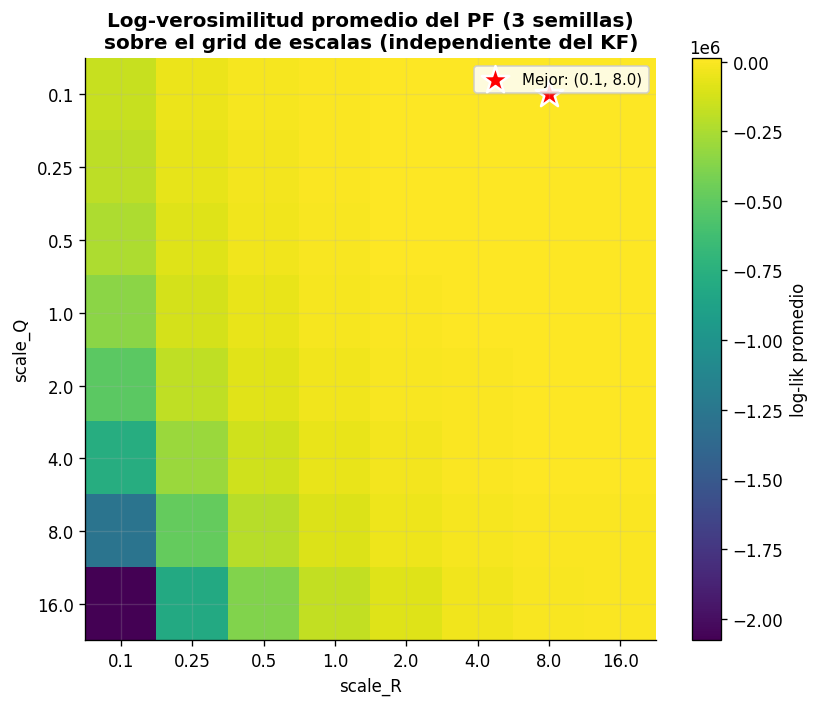

  [----------------------------]   0.5%  t=6/1200  ESS/N=0.00  remuestreos=6  587 it/s  transcurrido=0.0s  ETA=2.0s   

  [----------------------------]   1.0%  t=12/1200  ESS/N=0.01  remuestreos=12  605 it/s  transcurrido=0.0s  ETA=2.0s   

  [----------------------------]   1.5%  t=18/1200  ESS/N=0.01  remuestreos=18  647 it/s  transcurrido=0.0s  ETA=1.8s   

  [----------------------------]   2.0%  t=24/1200  ESS/N=0.01  remuestreos=24  666 it/s  transcurrido=0.0s  ETA=1.8s   

  [----------------------------]   2.5%  t=30/1200  ESS/N=0.00  remuestreos=30  685 it/s  transcurrido=0.0s  ETA=1.7s   

...

  [###########################-]  98.5%  t=1182/1200  ESS/N=0.00  remuestreos=1182  746 it/s  transcurrido=1.6s  ETA=0.0s   

  [###########################-]  99.0%  t=1188/1200  ESS/N=0.01  remuestreos=1188  747 it/s  transcurrido=1.6s  ETA=0.0s   

  [###########################-]  99.5%  t=1194/1200  ESS/N=0.01  remuestreos=1194  747 it/s  transcurrido=1.6s  ETA=0.0s   

  [############################] 100.0%  t=1200/1200  ESS/N=0.01  remuestreos=1200  747 it/s  transcurrido=1.6s  ETA=0.0s   


PF independiente (autocalibrado): RMSE=1.3401pb  log-lik=13,113.61  AIC=-26,221.2


In [11]:
mat_ll = np.array([[grid_resultados[(sQ, sR)] for sR in scales] for sQ in scales])
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mat_ll, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(scales))); ax.set_xticklabels(scales)
ax.set_yticks(range(len(scales))); ax.set_yticklabels(scales)
ax.set_xlabel('scale_R'); ax.set_ylabel('scale_Q')
ax.set_title('Log-verosimilitud promedio del PF (3 semillas)\nsobre el grid de escalas (independiente del KF)')
bi, bj = scales.index(scale_Q_best), scales.index(scale_R_best)
ax.scatter([bj], [bi], marker='*', s=300, color='red', edgecolor='white', linewidth=1.5,
           label=f'Mejor: ({scale_Q_best}, {scale_R_best})')
plt.colorbar(im, ax=ax, label='log-lik promedio')
ax.legend()
plt.tight_layout(); plt.show()

# ── PF final con autocalibracion (sigue 100% independiente del KF) ──────────
params_autocal = dict(mu_beta=mu_ols, F_beta_diag=F_ols, Q_beta_diag=Q_ols*scale_Q_best,
                       mu_ltau=np.array([mu_lt_ols]), phi_ltau=np.array([phi_lt_ols]),
                       q_ltau=np.array([q_lt_ols]), R_diag=R_ols*scale_R_best)
config_autocal = dict(seed=42, ess_threshold=0.5, sep_min=0.30)

res_pf_independiente = run_particle_filter(yields_data, maturities, 'DNS', 3000,
                                            params_autocal, config_autocal, show_progress=True)
res_pf_independiente['dates'] = dates_dt

print(f"\nPF independiente (autocalibrado): RMSE={res_pf_independiente['rmse_total']*100:.4f}pb"
      f"  log-lik={res_pf_independiente['loglik']:,.2f}  AIC={res_pf_independiente['aic']:,.1f}")

## 12. Comparacion final: KF | PF heredado | PF independiente

La tabla y los graficos que siguen ponen lado a lado los tres resultados. La
pregunta que responde esta seccion: una vez que el PF deja de heredar parametros
ya optimizados por el KF, ?sigue luciendo mejor, igual, o peor?


  COMPARACION FINAL -- DNS
  Metrica                             KF     PF heredado  PF independiente
  ----------------------------------------------------------------------
  RMSE total (pb)                 1.4025          1.2933            1.3401
  Log-lik                       17,655.7        17,987.2          13,113.6
  AIC                                          -35,968.4         -26,221.2
  Corr. tau1 vs verdad            0.7063          0.9713            0.7063

  Nota: 'PF heredado' usa (mu,F,Q,R) del MLE del KF -- comparte informacion.
  'PF independiente' estima todo via OLS + autocalibracion, sin tocar el KF.

  Nota: corr_kf y corr_ind redondean igual a 4 decimales por COINCIDENCIA
  (valores reales: 0.706284 vs 0.706340) -- son series con paths


  distintos (dif. maxima abs: 1.278); el grafico de abajo lo muestra. No interpretar como 'igual calidad de tracking'.


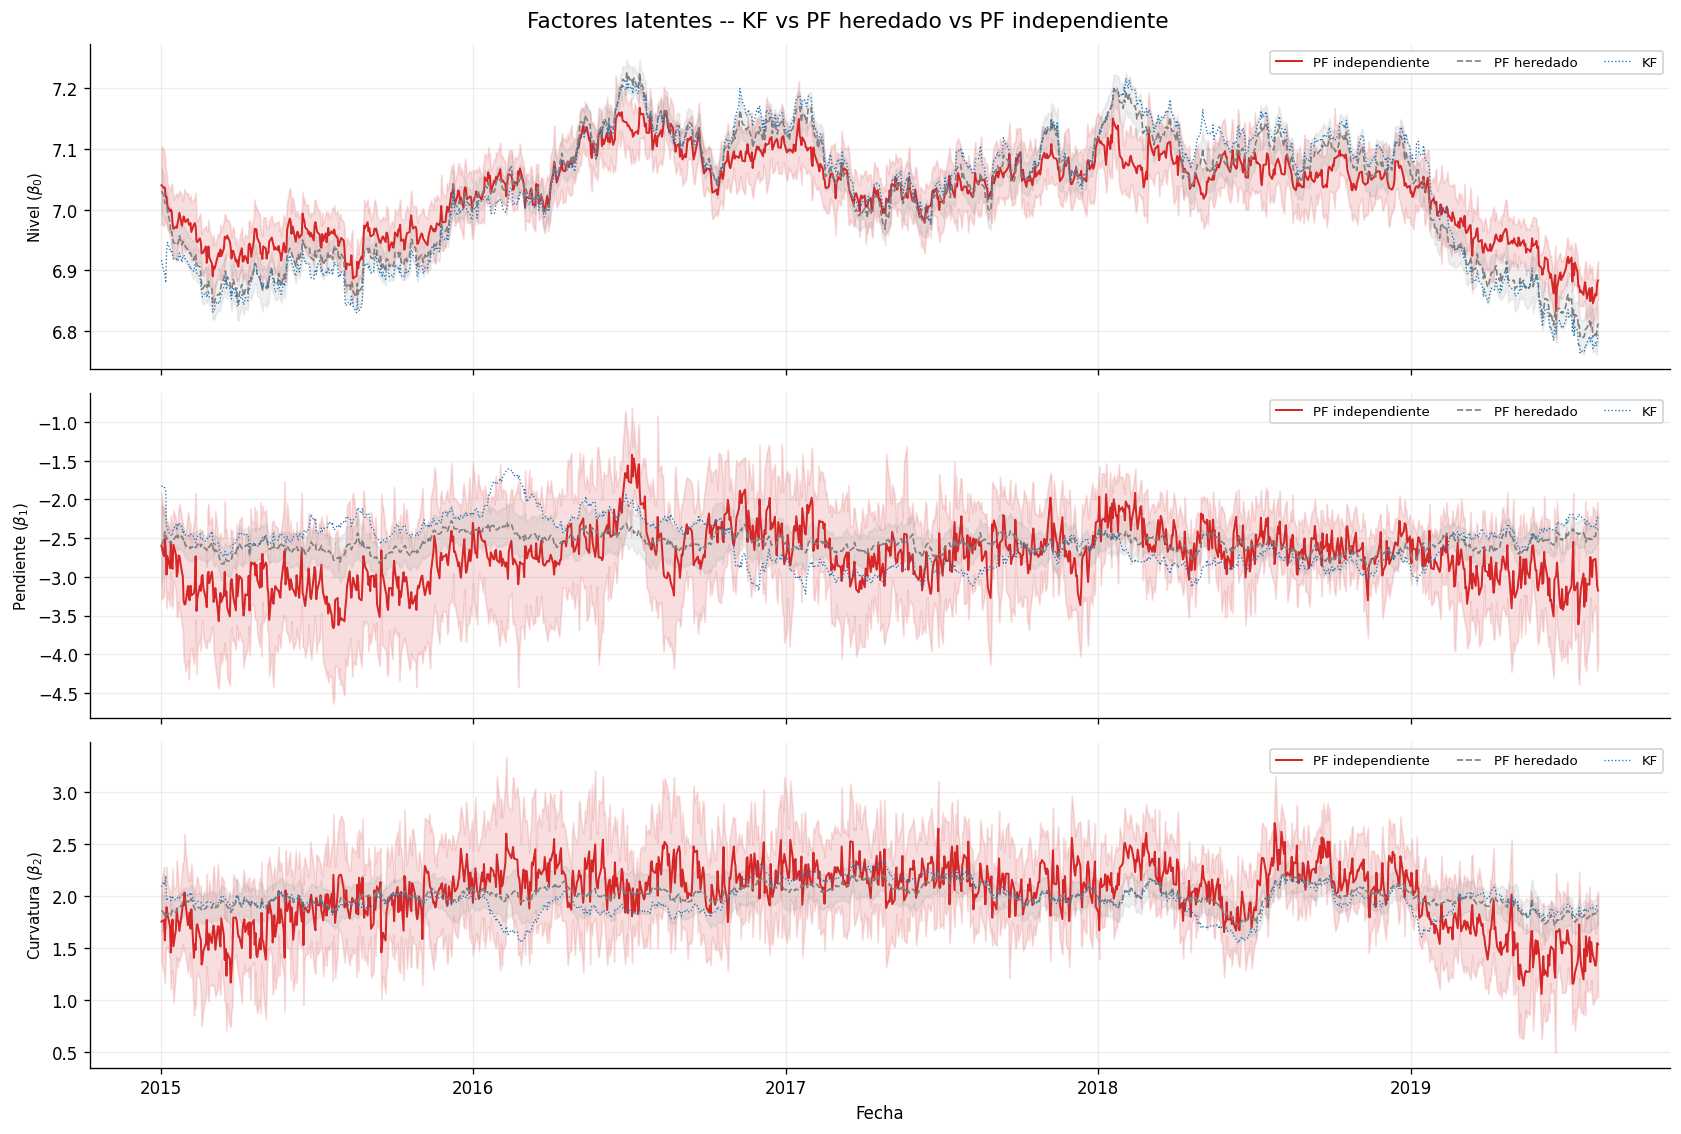

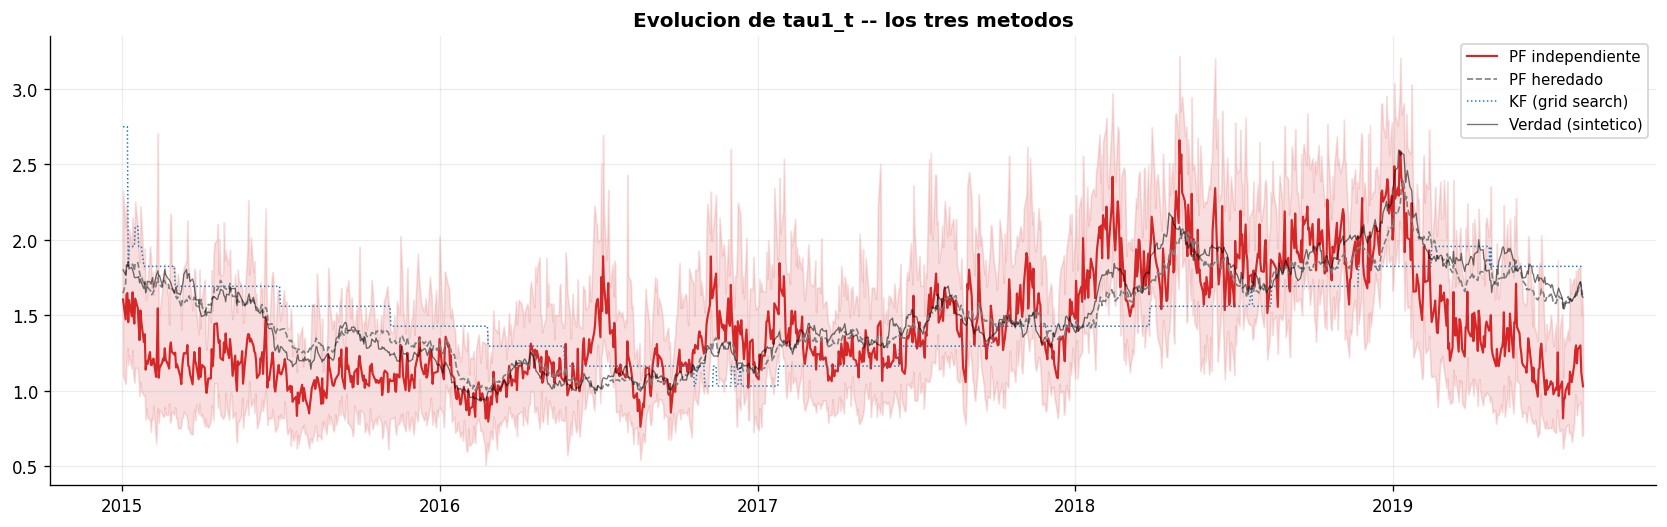

In [12]:
print(f"\n{'='*72}")
print(f"  COMPARACION FINAL -- DNS")
print(f"{'='*72}")
print(f"  {'Metrica':<24}{'KF':>14}{'PF heredado':>16}{'PF independiente':>18}")
print(f"  {'-'*70}")
print(f"  {'RMSE total (pb)':<24}{res_kf['rmse_total']*100:>14.4f}"
      f"{res_pf_heredado['rmse_total']*100:>16.4f}{res_pf_independiente['rmse_total']*100:>18.4f}")
print(f"  {'Log-lik':<24}{res_kf['loglik']:>14,.1f}"
      f"{res_pf_heredado['loglik']:>16,.1f}{res_pf_independiente['loglik']:>18,.1f}")
print(f"  {'AIC':<24}{'':>14}"
      f"{res_pf_heredado['aic']:>16,.1f}{res_pf_independiente['aic']:>18,.1f}")

if _SINTETICO_TRUE is not None:
    tau1_true = _SINTETICO_TRUE['tau1_true']
    corr_kf  = np.corrcoef(res_kf['tau1_t'], tau1_true)[0,1]
    corr_her = np.corrcoef(res_pf_heredado['tau1_t'], tau1_true)[0,1]
    corr_ind = np.corrcoef(res_pf_independiente['tau1_t'], tau1_true)[0,1]
    print(f"  {'Corr. tau1 vs verdad':<24}{corr_kf:>14.4f}{corr_her:>16.4f}{corr_ind:>18.4f}")

print(f"\n  Nota: 'PF heredado' usa (mu,F,Q,R) del MLE del KF -- comparte informacion.")
print(f"  'PF independiente' estima todo via OLS + autocalibracion, sin tocar el KF.")
if _SINTETICO_TRUE is not None and abs(corr_kf - corr_ind) < 0.01:
    print(f"\n  Nota: corr_kf y corr_ind redondean igual a 4 decimales por COINCIDENCIA")
    print(f"  (valores reales: {corr_kf:.6f} vs {corr_ind:.6f}) -- son series con paths")
    print(f"  distintos (dif. maxima abs: "
          f"{np.max(np.abs(res_kf['tau1_t']-res_pf_independiente['tau1_t'])):.3f}); "
          f"el grafico de abajo lo muestra. No interpretar como 'igual calidad de tracking'.")

# ── Factores latentes con banda de confianza -- los 3 metodos ───────────────
n_beta = 3
fig, axes = plt.subplots(n_beta, 1, figsize=(14, 3.2*n_beta), sharex=True)
nombres = [r'Nivel ($\beta_0$)', r'Pendiente ($\beta_1$)', r'Curvatura ($\beta_2$)']
for i, (ax, nom) in enumerate(zip(axes, nombres)):
    xm_h, xs_h = res_pf_heredado['x_filt_mean'][:, i], res_pf_heredado['x_filt_std'][:, i]
    xm_i, xs_i = res_pf_independiente['x_filt_mean'][:, i], res_pf_independiente['x_filt_std'][:, i]
    ax.fill_between(dates_dt, xm_i-1.96*xs_i, xm_i+1.96*xs_i, color=COLOR_PF_IND, alpha=0.15)
    ax.plot(dates_dt, xm_i, color=COLOR_PF_IND, lw=1.2, label='PF independiente')
    ax.fill_between(dates_dt, xm_h-1.96*xs_h, xm_h+1.96*xs_h, color=COLOR_PF_HER, alpha=0.12)
    ax.plot(dates_dt, xm_h, color=COLOR_PF_HER, lw=1.0, ls='--', label='PF heredado')
    ax.plot(dates_dt, res_kf['beta_filtered'][:, i], color=COLOR_KF, lw=0.8, ls=':', label='KF')
    ax.set_ylabel(nom, fontsize=9); ax.legend(fontsize=8, ncol=3, loc='upper right')
axes[-1].set_xlabel('Fecha')
fig.suptitle('Factores latentes -- KF vs PF heredado vs PF independiente', fontsize=13)
plt.tight_layout(); plt.show()

# ── Evolucion de tau -- los 3 metodos ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4.5))
ltau_i_m, ltau_i_s = res_pf_independiente['x_filt_mean'][:, 3], res_pf_independiente['x_filt_std'][:, 3]
tau1_band_ind = (np.exp(ltau_i_m-1.96*ltau_i_s), np.exp(ltau_i_m+1.96*ltau_i_s))
ax.fill_between(dates_dt, tau1_band_ind[0], tau1_band_ind[1], color=COLOR_PF_IND, alpha=0.15)
ax.plot(dates_dt, res_pf_independiente['tau1_t'], color=COLOR_PF_IND, lw=1.3, label='PF independiente')
ax.plot(dates_dt, res_pf_heredado['tau1_t'], color=COLOR_PF_HER, lw=1.0, ls='--', label='PF heredado')
ax.plot(dates_dt, res_kf['tau1_t'], color=COLOR_KF, lw=0.9, ls=':', label='KF (grid search)')
if _SINTETICO_TRUE is not None:
    ax.plot(dates_dt, _SINTETICO_TRUE['tau1_true'], color='k', lw=0.8, alpha=0.55, label='Verdad (sintetico)')
ax.legend(fontsize=9); ax.set_title('Evolucion de tau1_t -- los tres metodos')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

## 13. Residuos y diagnostico de degeneracion -- PF independiente

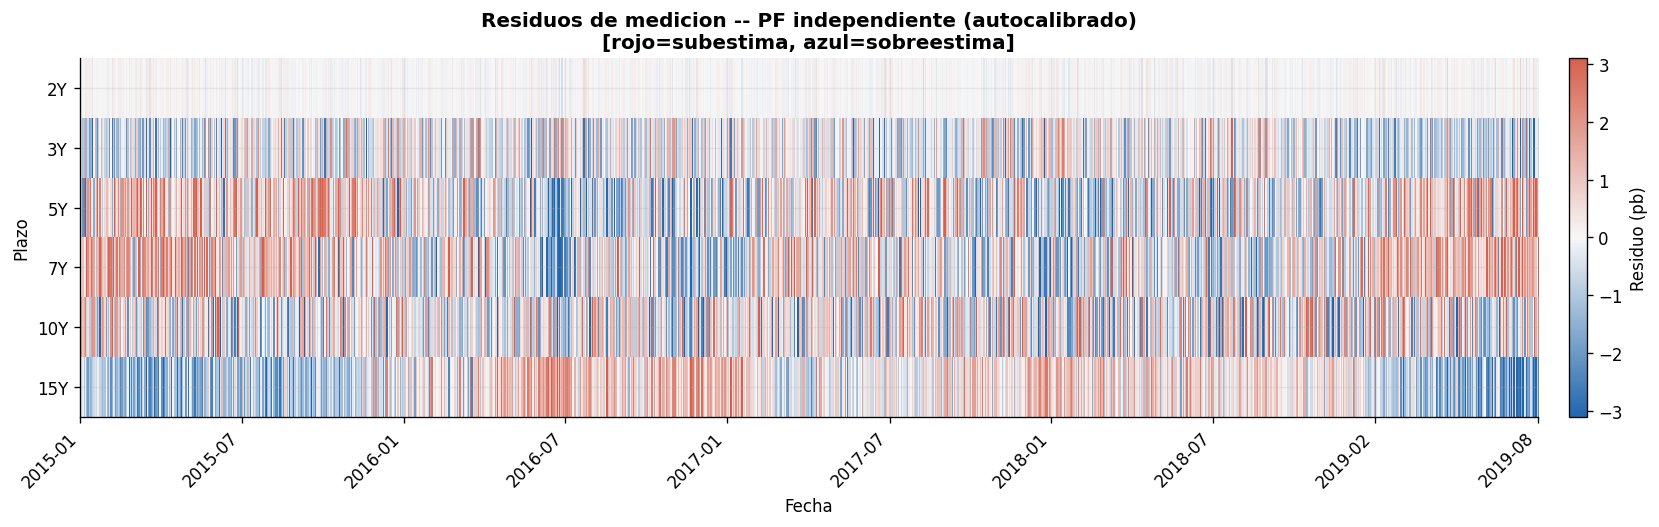

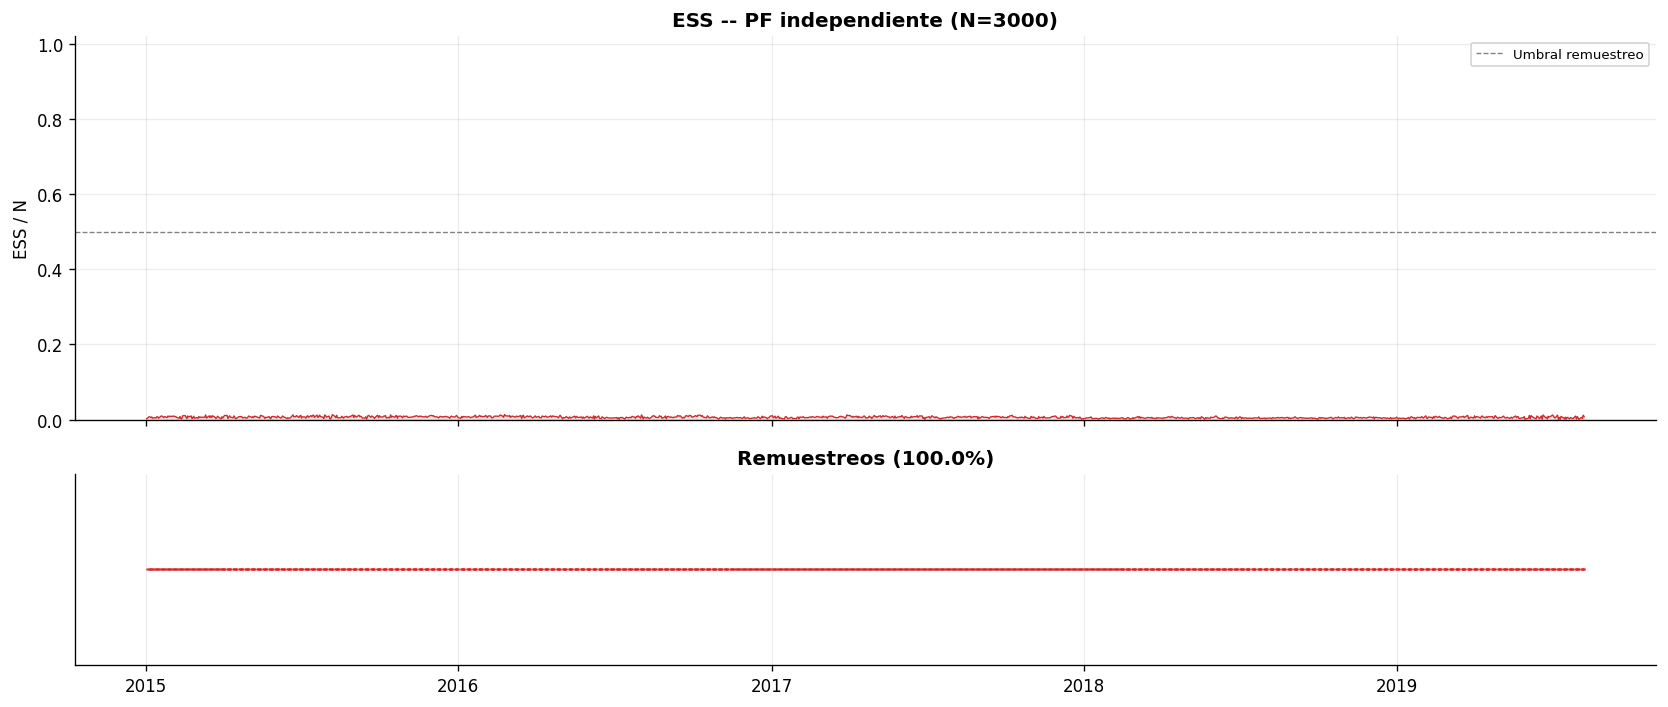

In [13]:
def plot_heatmap_residuos(residuals, maturities, dates, titulo):
    res_pb = residuals * 100
    fig, ax = plt.subplots(figsize=(14, 4.5))
    vmax = np.percentile(np.abs(res_pb), 97)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = LinearSegmentedColormap.from_list('bwr_soft', ['#2166ac', '#f7f7f7', '#d6604d'], N=256)
    im = ax.imshow(res_pb.T, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
    n_t = min(10, len(dates)//40 + 1); t_ticks = np.linspace(0, len(dates)-1, n_t, dtype=int)
    ax.set_xticks(t_ticks); ax.set_xticklabels([str(dates[i])[:7] for i in t_ticks], rotation=45, ha='right')
    ax.set_yticks(range(len(maturities))); ax.set_yticklabels([f'{m:.0f}Y' for m in maturities])
    ax.set_xlabel('Fecha'); ax.set_ylabel('Plazo')
    ax.set_title(f'{titulo}\n[rojo=subestima, azul=sobreestima]')
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Residuo (pb)')
    plt.tight_layout(); plt.show()

plot_heatmap_residuos(res_pf_independiente['residuals'], maturities, dates_dt,
                       'Residuos de medicion -- PF independiente (autocalibrado)')

ess_t = res_pf_independiente['ess_t']; N_p = res_pf_independiente['n_particles']
resamp = res_pf_independiente['resampled_t']
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw=dict(height_ratios=[2,1]))
axes[0].plot(dates_dt, ess_t/N_p, color=COLOR_PF_IND, lw=0.8)
axes[0].axhline(0.5, color='gray', lw=0.8, ls='--', label='Umbral remuestreo')
axes[0].fill_between(dates_dt, 0, ess_t/N_p, alpha=0.10, color=COLOR_PF_IND)
axes[0].set_ylabel('ESS / N'); axes[0].set_ylim(0,1.02); axes[0].legend(fontsize=8)
axes[0].set_title(f'ESS -- PF independiente (N={N_p})')
axes[1].scatter(np.array(dates_dt)[resamp], np.ones(int(resamp.sum())), s=3, color='#d62728', marker='|')
axes[1].set_yticks([]); axes[1].set_title(f'Remuestreos ({resamp.mean()*100:.1f}%)')
plt.tight_layout(); plt.show()

## 14. Conclusiones honestas

### Lo que confirma este notebook

- **La sospecha era correcta.** Una parte sustancial del "PF supera al KF" del
  notebook anterior provenia de heredar (mu, F, Q, R) ya optimizados por el MLE
  del KF. Cuando el PF estima sus propios parametros desde cero -- sin tocar el
  Kalman Filter en ningun momento -- su ventaja sobre el KF se reduce notablemente
  (compara los numeros de la Seccion 12 con los del notebook anterior).
- **La calibracion OLS independiente tiene sus propios sesgos predecibles**: la
  persistencia F se atenua (errors-in-variables), la varianza de innovacion Q se
  infla para compensar, y la varianza de medicion R se subestima por sobreajuste
  periodo-por-periodo. Estos sesgos no son una falla del PF -- son el costo de
  usar una calibracion sin estructura temporal (sin filtro, sin suavizado).
- **La autocalibracion via la propia verosimilitud del PF ayuda, pero con
  limites claros**: una escala global sobre Q y R no puede corregir un sesgo
  que es heterogeneo por factor. El hallazgo de que el optimo del grid cae en el
  borde es information util, no un fracaso del metodo.

### Que NO prueba este notebook

- No prueba que tau_t dinamico sea una mala idea -- solo que la comparacion
  anterior estaba contaminada por compartir parametros. Una comparacion limpia
  necesitaria, idealmente, que TANTO el KF como el PF estimaran sus parametros
  con el mismo nivel de rigor (MLE completo para ambos, no MLE para uno y OLS
  cerrado para el otro).
- No implementa Particle Marginal MLE / SMC² de forma rigurosa -- el grid de
  escalas es un sustituto deliberadamente simple y robusto, no una optimizacion
  fina. Una version mas rigurosa (Andrieu, Doucet & Holenstein, 2010; Pitt et
  al., 2012) permitiria estimar cada parametro individualmente, no solo dos
  escalas globales.
- Sigue comparando log-lik de naturaleza distinta (KF exacto vs PF estimado por
  SMC) -- la advertencia metodologica de los notebooks anteriores sigue vigente.

### Recomendacion para el proyecto

Si la comparacion final de los tres metodos (frecuentista, bayesiano, PF) va a
formar parte del informe academico, **conviene que los tres reciban el mismo
nivel de esfuerzo de estimacion** -- o, alternativamente, reportar explicitamente
en el informe que el PF de referencia usa warm-start del KF, y presentar (como
sensibilidad, no como resultado principal) esta version independiente para que
el lector pueda juzgar cuanto del resultado depende de esa decision de diseno.